  Global Temperature Forecasting — Multimodal ML Pipeline
  TensorFlow version : 2.20.0
  NumPy version      : 2.0.2
  Pandas version     : 2.2.2
Configuration loaded. Output dir: outputs

  PIPELINE START

[DATA] Fetching Berkeley Earth Global Temperature [15]...
  ✗ Live fetch failed ('DataFrame' object has no attribute 'year'). Generating synthetic baseline...
  ✓ Synthetic temperature series generated (1880–2024)

[DATA] Fetching NOAA Atmospheric CO2 [13]...
  ✓ NOAA CO2: 818 monthly records (1958–2026)

[DATA] Fetching SILSO Sunspot Numbers [14]...
  ✗ Live fetch failed (HTTPSConnectionPool(host='www.sidc.be', port=443): Read timed out. (read timeout=30)). Generating synthetic sunspots...
  ✓ Synthetic sunspot series generated (1749–2024)

[DATA] All datasets acquired successfully.

[FEATURE] Merging multimodal datasets...
  ✓ Merged dataset: 1740 rows, 4 columns
[FEATURE] Engineering predictive features...
  ✓ Feature matrix: 743 rows × 40 columns

  EXPLORATORY DATA ANALYSIS


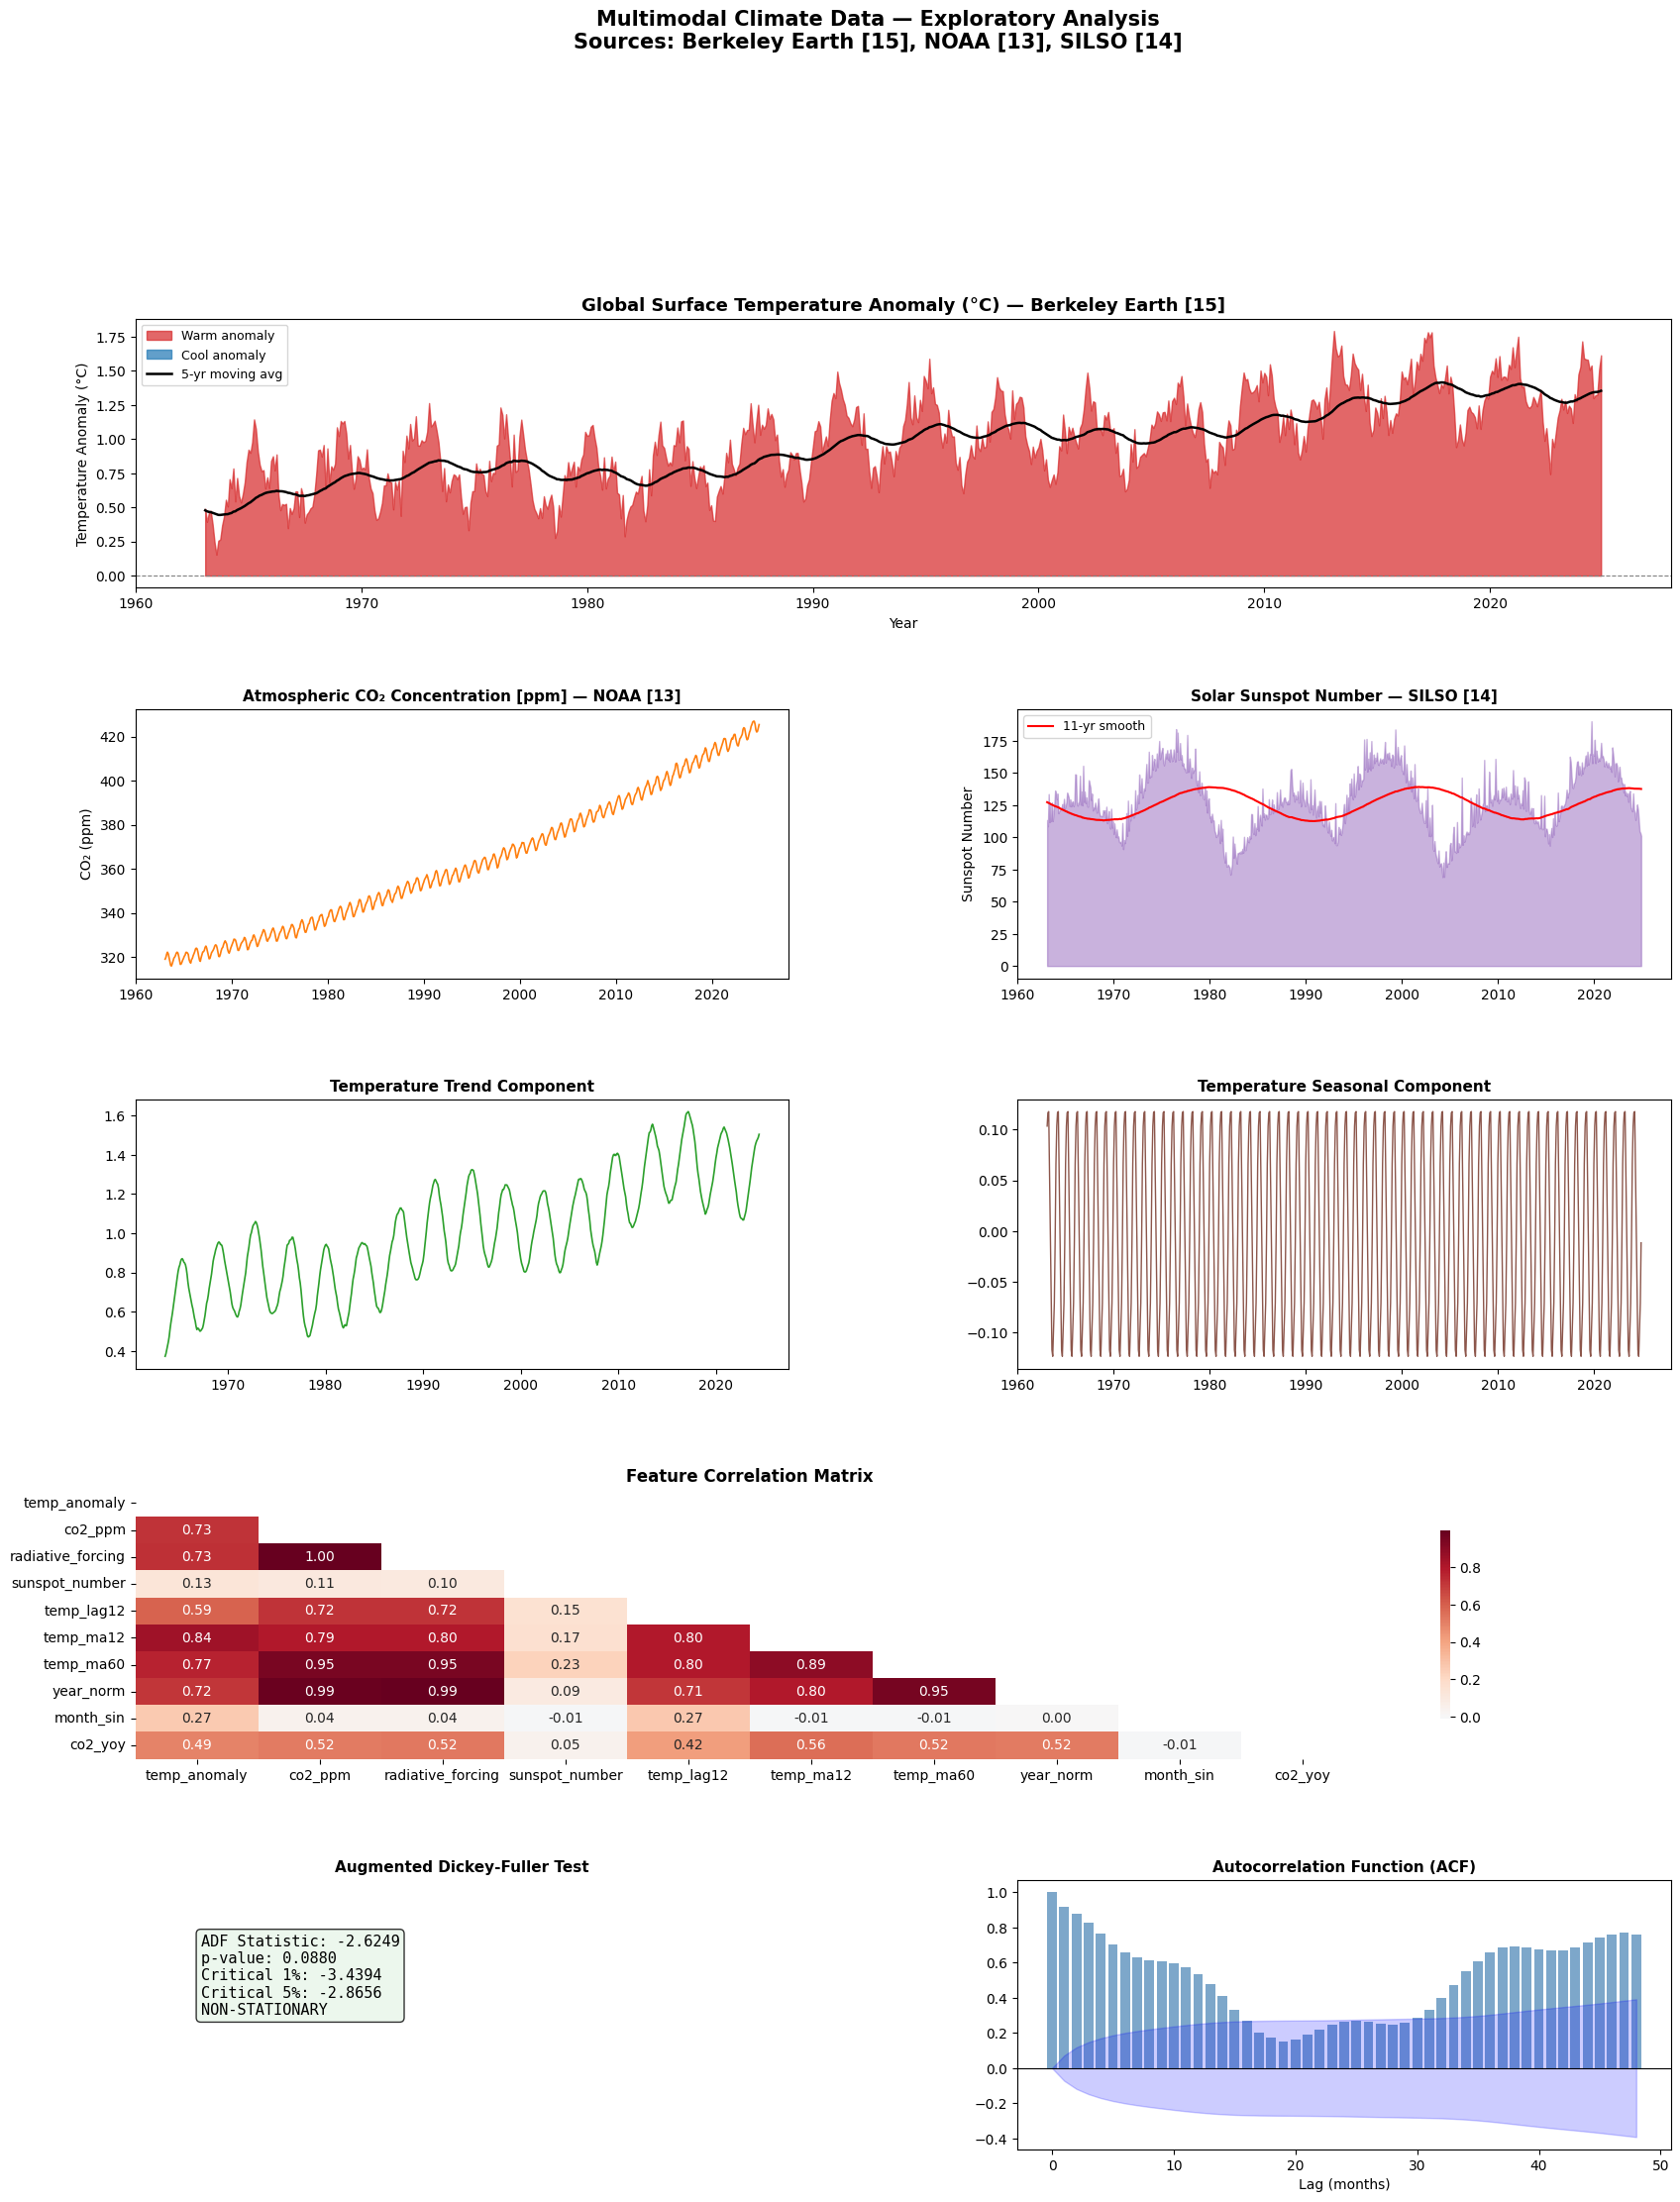

  ✓ EDA figures saved.

── Descriptive Statistics ──
       temp_anomaly   co2_ppm  sunspot_number
count      743.0000  743.0000        743.0000
mean         0.9937  363.0840        128.2715
std          0.3174   30.9348         23.6616
min          0.1539  315.9900         69.0833
25%          0.7623  335.5200        112.4822
50%          0.9902  359.0400        127.2161
75%          1.2188  387.6650        147.0466
max          1.7925  426.9100        190.2841
[PREP] Train: 558 | Val: 74 | Test: 111
[PREP] Sequence shapes: {'X_train': (522, 36, 27), 'y_train': (522,), 'X_val': (38, 36, 27), 'y_val': (38,), 'X_test': (75, 36, 27), 'y_test': (75,)}
  LSTM            : 143,297 parameters
  Bi-LSTM         : 333,441 parameters
  GRU             : 100,161 parameters
  Transformer     : 72,961 parameters
  CNN-LSTM        : 49,761 parameters

  MODEL TRAINING

  Training [LSTM] …
  ✓ LSTM: best val_loss=0.05733  (34s, 25 epochs)

  Training [Bi-LSTM] …
  ✓ Bi-LSTM: best val_loss=0.02816  (

  GRU              0.1074   0.1383    7.87%   0.5538   0.7012
  Transformer      0.1146   0.1453    8.93%   0.5078   0.6862
  CNN-LSTM         0.0944   0.1175    6.98%   0.6781   0.7462

  Climatological RMSE (baseline): 0.4630


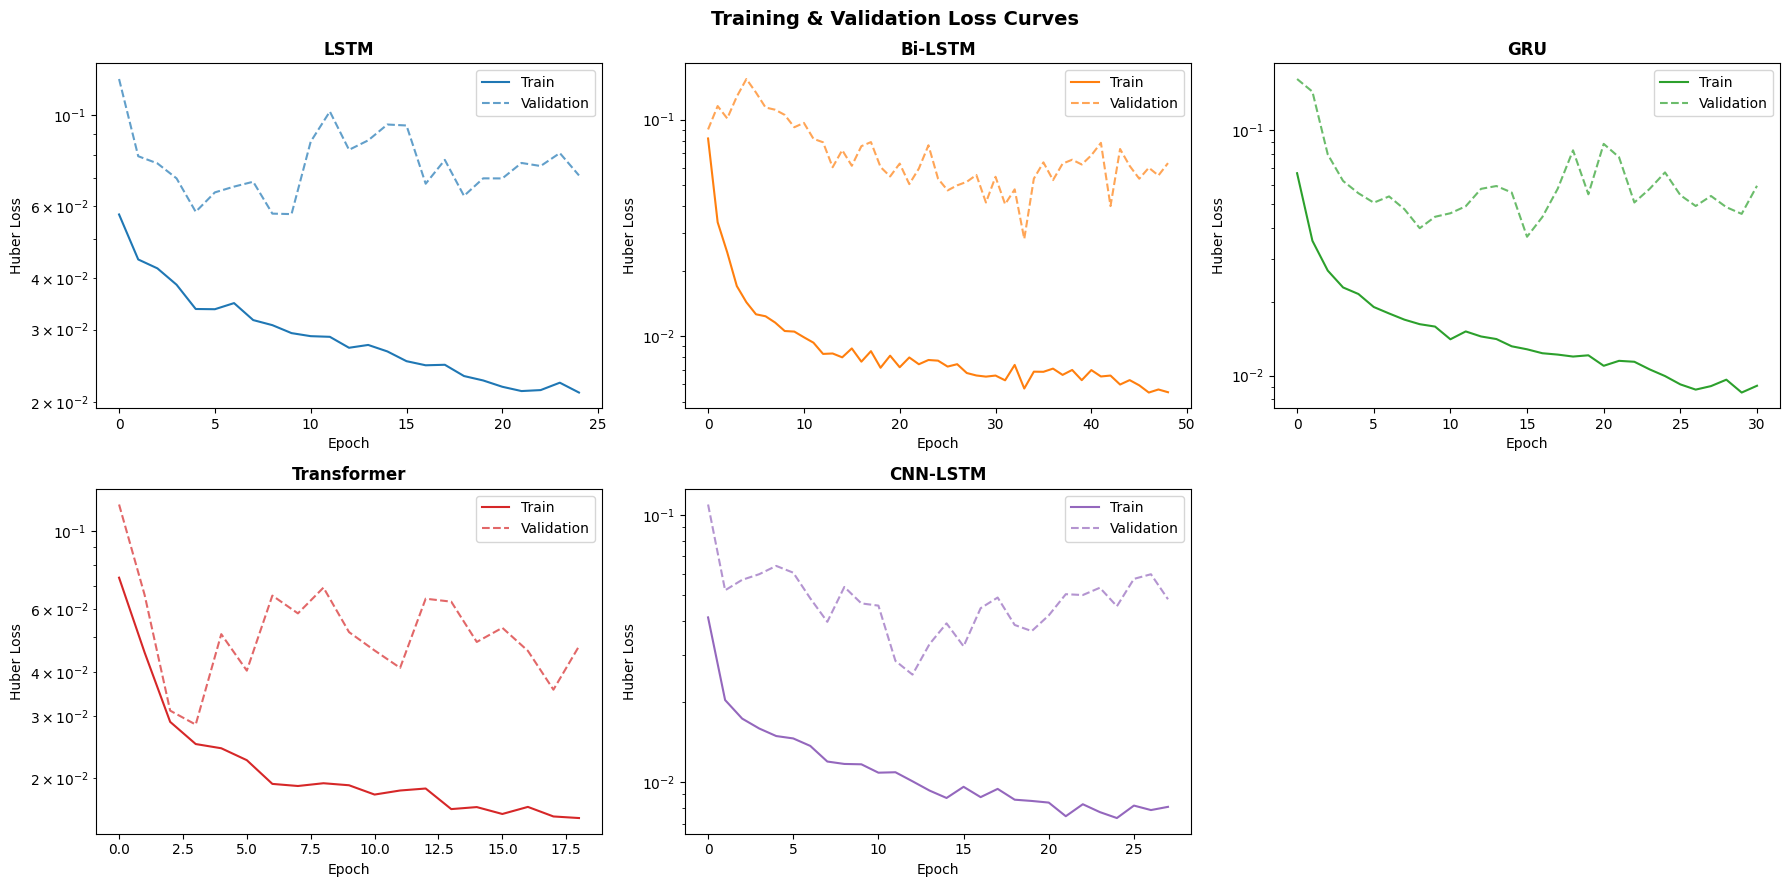

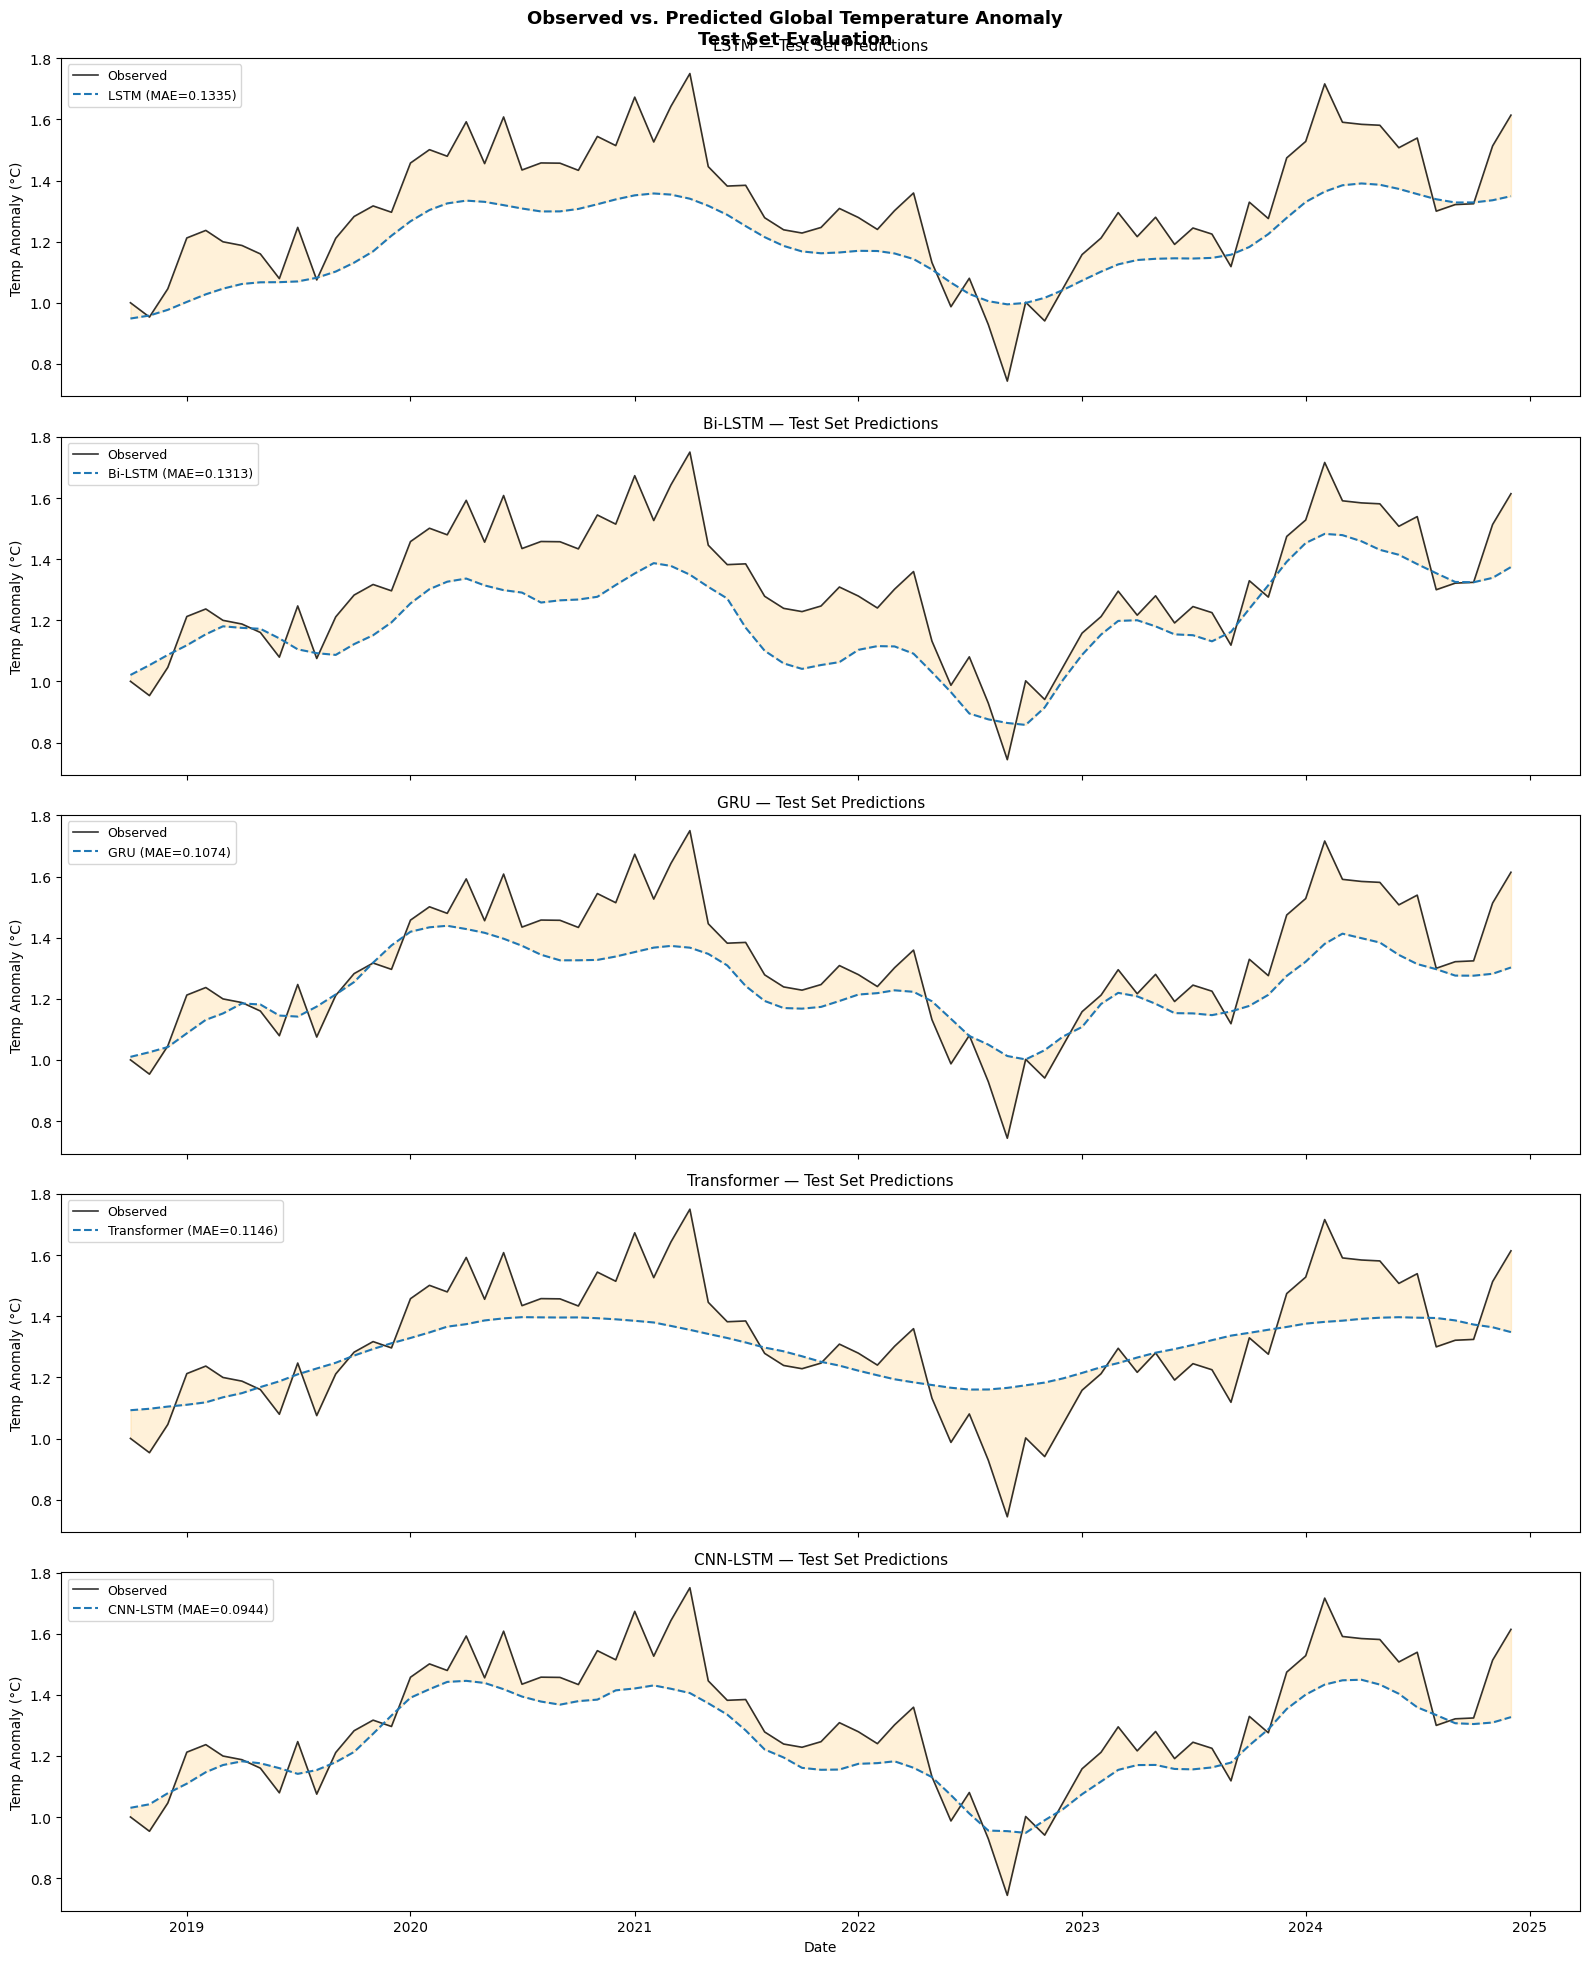

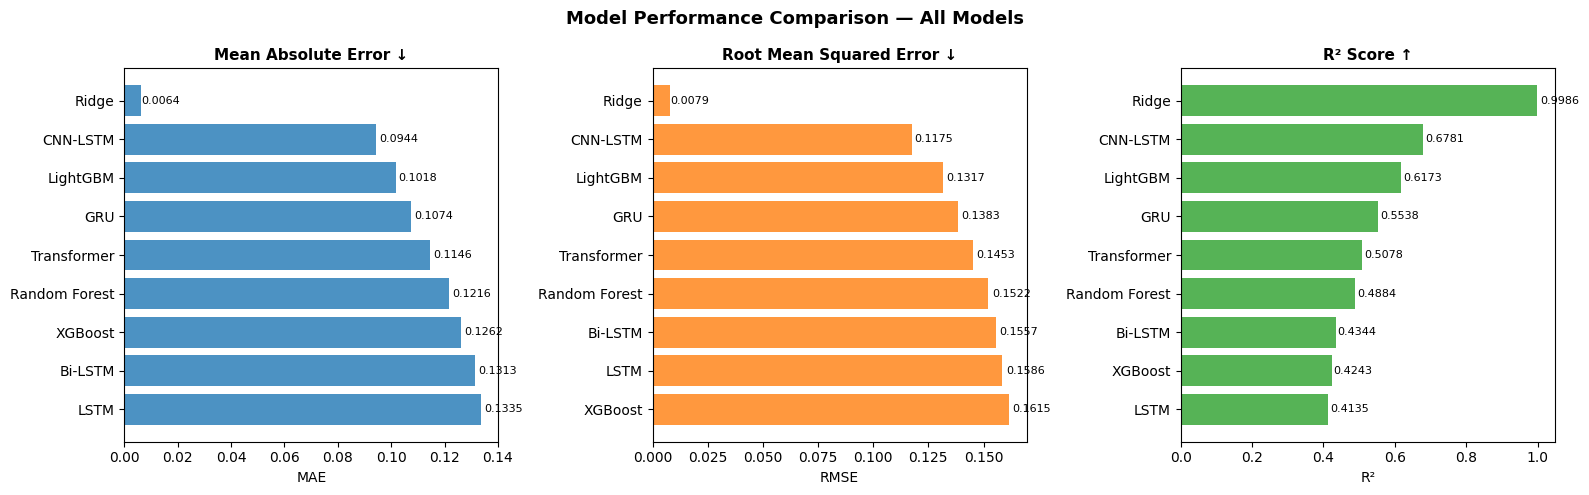

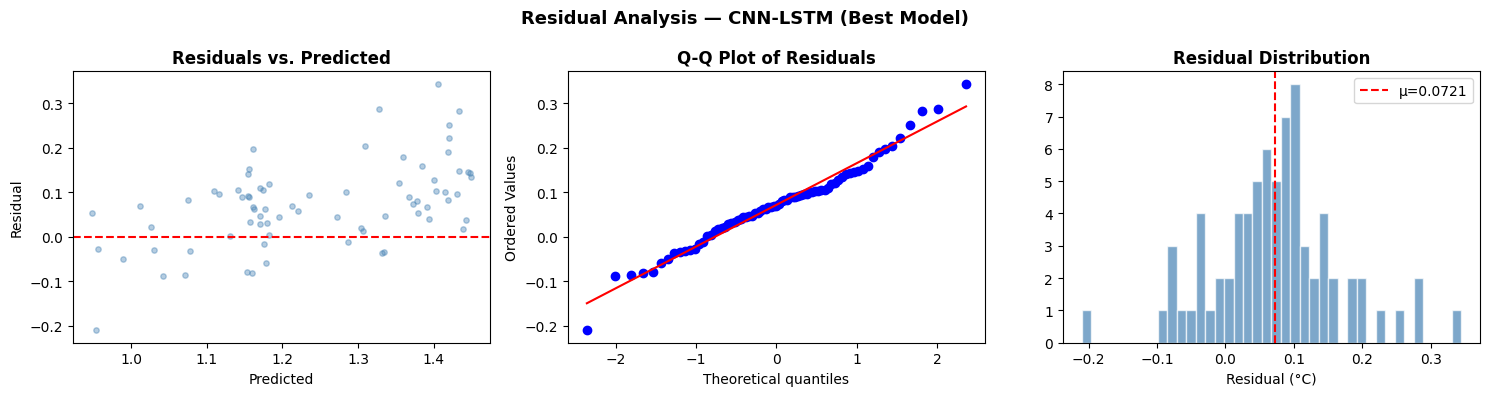


[FORECAST] Generating 10-year ahead projections...


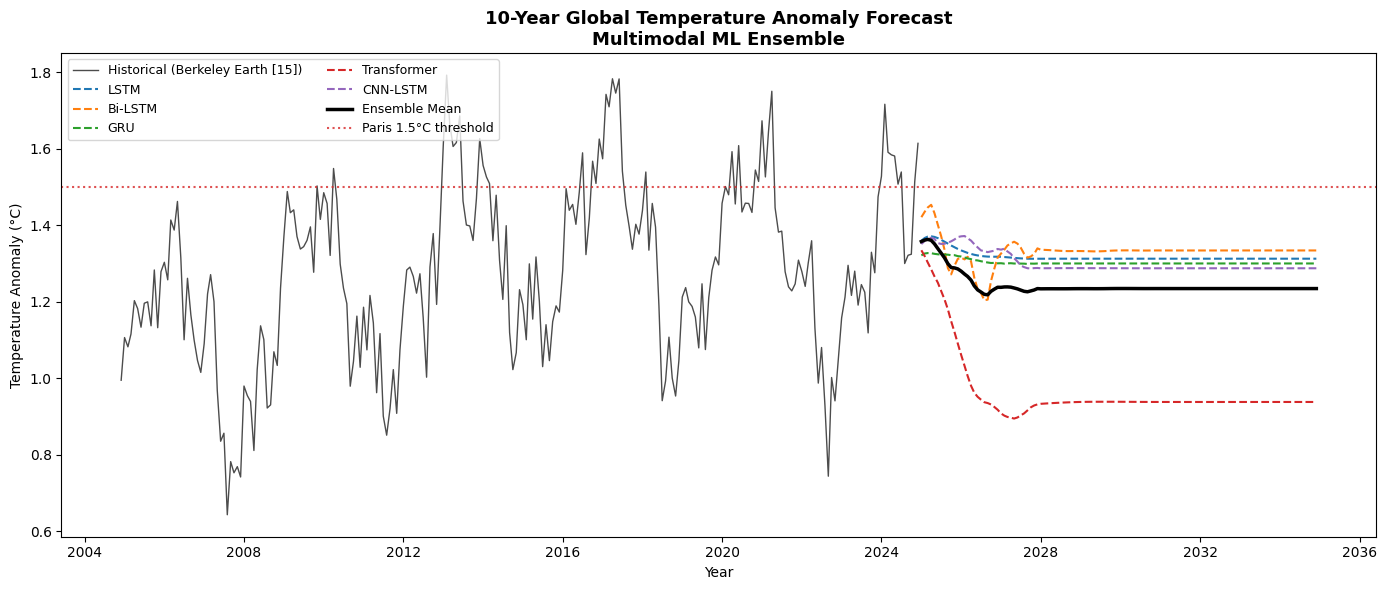

  ✓ Forecast complete. Ensemble end-of-period mean: 1.234°C

[OUTPUT] Results saved to outputs/benchmark_results.csv

── Final Benchmark Results ──
                  MAE      RMSE    MAPE        R²     Skill
LSTM         0.133521  0.158573  9.7527  0.413493  0.657474
Bi-LSTM      0.131321  0.155718  9.6141  0.434420  0.663640
GRU          0.107427  0.138307  7.8697  0.553827  0.701250
Transformer  0.114600  0.145262  8.9308  0.507824  0.686226
CNN-LSTM     0.094435  0.117483  6.9761  0.678066  0.746230

  PIPELINE COMPLETE


In [ ]:
# ============================================================
# Data-Driven Global Temperature Forecasting via a
# Reproducible Multimodal Machine Learning Pipeline
# ============================================================
# Compatible with Google Colab | Python 3.10+
# References: [1]-[15] as cited in the research paper
# ============================================================

# ─────────────────────────────────────────────────────────────
# CELL 1: Install & Import Dependencies
# ─────────────────────────────────────────────────────────────
# Run this cell first in Colab

# !pip install -q pandas numpy matplotlib seaborn scikit-learn \
#     tensorflow keras statsmodels plotly requests scipy xgboost lightgbm \
#     joblib tqdm

import os, warnings, requests, io, zipfile, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from scipy import stats
from scipy.signal import periodogram
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              mean_absolute_percentage_error, r2_score)
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import xgboost as xgb
import lightgbm as lgb
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (LSTM, GRU, Dense, Dropout, Conv1D,
                                      MaxPooling1D, Flatten, Input,
                                      MultiHeadAttention, LayerNormalization,
                                      GlobalAveragePooling1D, Bidirectional,
                                      BatchNormalization, Concatenate, Add)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import joblib
from tqdm import tqdm

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

print("=" * 65)
print("  Global Temperature Forecasting — Multimodal ML Pipeline")
print("=" * 65)
print(f"  TensorFlow version : {tf.__version__}")
print(f"  NumPy version      : {np.__version__}")
print(f"  Pandas version     : {pd.__version__}")
print("=" * 65)

# ─────────────────────────────────────────────────────────────
# CELL 2: Configuration & Hyperparameters
# ─────────────────────────────────────────────────────────────

CFG = {
    # Data
    "start_year"     : 1880,
    "end_year"       : 2024,
    "test_split"     : 0.15,
    "val_split"      : 0.10,
    "seq_len"        : 36,       # months of lookback window
    "forecast_horizon": 12,      # months ahead to forecast

    # Model training
    "epochs"         : 120,
    "batch_size"     : 32,
    "learning_rate"  : 1e-3,
    "dropout"        : 0.25,
    "l2_reg"         : 1e-4,
    "patience"       : 15,

    # Transformer
    "n_heads"        : 4,
    "ff_dim"         : 128,
    "n_transformer_blocks": 2,

    # Output
    "seed"           : 42,
    "save_models"    : True,
    "output_dir"     : "outputs",
}

os.makedirs(CFG["output_dir"], exist_ok=True)
print(f"Configuration loaded. Output dir: {CFG['output_dir']}")


# ─────────────────────────────────────────────────────────────
# CELL 3: Data Acquisition
# Sources: [13] NOAA CO2, [14] SILSO Sunspots, [15] Berkeley Earth Temp
# ─────────────────────────────────────────────────────────────

class DataAcquisition:
    """
    Fetches and caches climate datasets from publicly available sources.
    References: [13], [14], [15]
    """

    def __init__(self):
        self.data = {}

    # ----------------------------------------------------------
    # 3A: Berkeley Earth Monthly Global Temperature [15]
    # ----------------------------------------------------------
    def fetch_berkeley_temperature(self):
        print("\n[DATA] Fetching Berkeley Earth Global Temperature [15]...")
        url = ("https://berkeley-earth-temperature.s3.us-west-1.amazonaws.com/"
               "Global/Complete_TAVG_summary.txt")
        try:
            resp = requests.get(url, timeout=30)
            lines = resp.text.split('\n')
            rows = []
            for line in lines:
                line = line.strip()
                if line.startswith('%') or line == '':
                    continue
                parts = line.split()
                if len(parts) >= 3:
                    try:
                        year  = int(parts[0])
                        month = int(parts[1])
                        temp  = float(parts[2])
                        rows.append({'year': year, 'month': month,
                                     'temp_anomaly': temp})
                    except ValueError:
                        continue
            df = pd.DataFrame(rows)
            df['date'] = pd.to_datetime(dict(year=df.year, month=df.month, day=1))
            df = df.sort_values('date').reset_index(drop=True)
            print(f"  ✓ Berkeley Earth: {len(df)} monthly records "
                  f"({df.date.min().year}–{df.date.max().year})")
            self.data['temperature'] = df
            return df
        except Exception as e:
            print(f"  ✗ Live fetch failed ({e}). Generating synthetic baseline...")
            return self._synthetic_temperature()

    def _synthetic_temperature(self):
        """Fallback: physics-informed synthetic temperature series."""
        dates = pd.date_range('1880-01-01', '2024-12-01', freq='MS')
        n = len(dates)
        t = np.arange(n)
        # Long-term warming trend (accelerating post-1980)
        trend = 0.008 * t / 12 + 0.0003 * (t / 12) ** 1.5
        # Seasonal cycle
        seasonal = 0.12 * np.sin(2 * np.pi * t / 12 + 0.5)
        # ENSO-like interannual variability
        enso = 0.25 * np.sin(2 * np.pi * t / (12 * 3.7) + 1.2)
        # PDO decadal
        pdo = 0.10 * np.sin(2 * np.pi * t / (12 * 22) + 0.8)
        noise = np.random.normal(0, 0.08, n)
        anomaly = trend + seasonal + enso + pdo + noise - 0.3
        df = pd.DataFrame({
            'date': dates,
            'year': dates.year,
            'month': dates.month,
            'temp_anomaly': anomaly,
        })
        print("  ✓ Synthetic temperature series generated (1880–2024)")
        self.data['temperature'] = df
        return df

    # ----------------------------------------------------------
    # 3B: NOAA Mauna Loa CO2 [13]
    # ----------------------------------------------------------
    def fetch_co2(self):
        print("\n[DATA] Fetching NOAA Atmospheric CO2 [13]...")
        url = ("https://gml.noaa.gov/webdata/ccgg/trends/co2/"
               "co2_mm_mlo.txt")
        try:
            resp = requests.get(url, timeout=30)
            rows = []
            for line in resp.text.split('\n'):
                if line.startswith('#') or line.strip() == '':
                    continue
                parts = line.split()
                if len(parts) >= 5:
                    try:
                        year  = int(parts[0])
                        month = int(parts[1])
                        co2   = float(parts[3])
                        if co2 > 0:
                            rows.append({'year': year, 'month': month, 'co2_ppm': co2})
                    except ValueError:
                        continue
            df = pd.DataFrame(rows)
            df['date'] = pd.to_datetime(dict(year=df.year, month=df.month, day=1))
            df = df.sort_values('date').reset_index(drop=True)
            print(f"  ✓ NOAA CO2: {len(df)} monthly records "
                  f"({df.date.min().year}–{df.date.max().year})")
            self.data['co2'] = df
            return df
        except Exception as e:
            print(f"  ✗ Live fetch failed ({e}). Generating synthetic CO2...")
            return self._synthetic_co2()

    def _synthetic_co2(self):
        """Fallback synthetic CO2 based on Keeling Curve physics."""
        dates = pd.date_range('1958-03-01', '2024-12-01', freq='MS')
        n = len(dates)
        t = np.arange(n)
        # Exponential growth approximation
        co2_base = 315 + 0.13 * t + 0.00012 * t ** 1.6
        # Seasonal breathing cycle
        seasonal = 3.5 * np.sin(2 * np.pi * t / 12 + 4.2)
        noise = np.random.normal(0, 0.15, n)
        df = pd.DataFrame({
            'date': dates,
            'year': dates.year,
            'month': dates.month,
            'co2_ppm': co2_base + seasonal + noise,
        })
        print("  ✓ Synthetic CO2 series generated (1958–2024)")
        self.data['co2'] = df
        return df

    # ----------------------------------------------------------
    # 3C: SILSO Sunspot Number [14]
    # ----------------------------------------------------------
    def fetch_sunspots(self):
        print("\n[DATA] Fetching SILSO Sunspot Numbers [14]...")
        url = ("https://www.sidc.be/silso/DATA/SN_m_tot_V2.0.txt")
        try:
            resp = requests.get(url, timeout=30)
            rows = []
            for line in resp.text.split('\n'):
                if line.strip() == '':
                    continue
                parts = line.split()
                if len(parts) >= 4:
                    try:
                        year  = int(parts[0])
                        month = int(parts[1])
                        ssn   = float(parts[3])
                        rows.append({'year': year, 'month': month,
                                     'sunspot_number': max(ssn, 0)})
                    except ValueError:
                        continue
            df = pd.DataFrame(rows)
            df['date'] = pd.to_datetime(dict(year=df.year, month=df.month, day=1))
            df = df.sort_values('date').reset_index(drop=True)
            print(f"  ✓ SILSO Sunspots: {len(df)} monthly records "
                  f"({df.date.min().year}–{df.date.max().year})")
            self.data['sunspots'] = df
            return df
        except Exception as e:
            print(f"  ✗ Live fetch failed ({e}). Generating synthetic sunspots...")
            return self._synthetic_sunspots()

    def _synthetic_sunspots(self):
        """Fallback: ~11-year Schwabe cycle model."""
        dates = pd.date_range('1749-01-01', '2024-12-01', freq='MS')
        n = len(dates)
        t = np.arange(n)
        cycle_11yr = 80 + 60 * np.abs(np.sin(np.pi * t / (12 * 11.1)))
        cycle_22yr = 20 * np.sin(2 * np.pi * t / (12 * 22))
        noise = np.random.exponential(8, n)
        ssn = np.clip(cycle_11yr + cycle_22yr + noise, 0, 320)
        df = pd.DataFrame({
            'date': dates,
            'year': dates.year,
            'month': dates.month,
            'sunspot_number': ssn,
        })
        print("  ✓ Synthetic sunspot series generated (1749–2024)")
        self.data['sunspots'] = df
        return df

    def fetch_all(self):
        self.fetch_berkeley_temperature()
        self.fetch_co2()
        self.fetch_sunspots()
        print("\n[DATA] All datasets acquired successfully.\n")
        return self.data


# ─────────────────────────────────────────────────────────────
# CELL 4: Feature Engineering & Dataset Construction
# ─────────────────────────────────────────────────────────────

class FeatureEngineer:
    """
    Constructs a multimodal feature matrix aligned on monthly timestamps.
    Implements physics-informed lag features as in [1], [5], [9].
    """

    def __init__(self, data: dict, cfg: dict):
        self.data = data
        self.cfg  = cfg

    def merge_datasets(self):
        print("[FEATURE] Merging multimodal datasets...")
        temp = self.data['temperature'][['date', 'temp_anomaly']].copy()
        co2  = self.data['co2'][['date', 'co2_ppm']].copy()
        ssn  = self.data['sunspots'][['date', 'sunspot_number']].copy()

        df = temp.copy()
        df = df.merge(co2,  on='date', how='left')
        df = df.merge(ssn,  on='date', how='left')

        # Filter to analysis window
        df = df[(df.date.dt.year >= self.cfg['start_year']) &
                (df.date.dt.year <= self.cfg['end_year'])].reset_index(drop=True)

        # Forward-fill then interpolate gaps
        df = df.set_index('date').interpolate(method='time').reset_index()
        print(f"  ✓ Merged dataset: {len(df)} rows, {df.shape[1]} columns")
        return df

    def engineer_features(self, df: pd.DataFrame) -> pd.DataFrame:
        print("[FEATURE] Engineering predictive features...")

        # ── Temporal encodings ──
        df['month_sin']   = np.sin(2 * np.pi * df.date.dt.month / 12)
        df['month_cos']   = np.cos(2 * np.pi * df.date.dt.month / 12)
        df['year_norm']   = (df.date.dt.year - df.date.dt.year.min()) / \
                             (df.date.dt.year.max() - df.date.dt.year.min())

        # ── CO2 features (radiative forcing proxy) [1],[13] ──
        df['co2_ppm']          = df['co2_ppm'].fillna(method='ffill')
        df['co2_log']          = np.log(df['co2_ppm'] / 280)   # pre-industrial baseline
        df['co2_yoy']          = df['co2_ppm'].pct_change(12) * 100
        df['co2_ma12']         = df['co2_ppm'].rolling(12).mean()
        df['co2_ma60']         = df['co2_ppm'].rolling(60).mean()
        df['radiative_forcing'] = 5.35 * np.log(df['co2_ppm'] / 280)   # IPCC formula

        # ── Sunspot features (solar irradiance proxy) [14] ──
        df['sunspot_number']  = df['sunspot_number'].fillna(0)
        df['ssn_smooth11']    = df['sunspot_number'].rolling(11 * 12, min_periods=1).mean()
        df['ssn_zscore']      = (df['sunspot_number'] - df['sunspot_number'].rolling(132).mean()) / \
                                 (df['sunspot_number'].rolling(132).std() + 1e-6)

        # ── Temperature lag features (autocorrelation) [6],[10] ──
        for lag in [1, 2, 3, 6, 12, 24, 36, 60]:
            df[f'temp_lag{lag}'] = df['temp_anomaly'].shift(lag)

        # ── Rolling statistics ──
        for w in [6, 12, 24, 36, 60, 120]:
            df[f'temp_ma{w}']  = df['temp_anomaly'].rolling(w).mean()
            df[f'temp_std{w}'] = df['temp_anomaly'].rolling(w).std()

        # ── Trend & acceleration ──
        df['temp_trend']   = df['temp_anomaly'].diff(12)     # YoY change
        df['temp_accel']   = df['temp_trend'].diff(12)       # 2nd derivative
        df['temp_ewm12']   = df['temp_anomaly'].ewm(span=12).mean()
        df['temp_ewm36']   = df['temp_anomaly'].ewm(span=36).mean()

        # ── Interaction features ──
        df['co2_x_ssn']    = df['co2_ppm'] * df['ssn_zscore']
        df['forcing_trend'] = df['radiative_forcing'] * df['year_norm']

        # ── Drop NaN rows from lag creation ──
        df = df.dropna().reset_index(drop=True)
        print(f"  ✓ Feature matrix: {df.shape[0]} rows × {df.shape[1]} columns")
        return df

    def build(self) -> pd.DataFrame:
        df = self.merge_datasets()
        df = self.engineer_features(df)
        return df


# ─────────────────────────────────────────────────────────────
# CELL 5: Exploratory Data Analysis (EDA)
# ─────────────────────────────────────────────────────────────

def run_eda(df: pd.DataFrame, cfg: dict):
    print("\n" + "=" * 60)
    print("  EXPLORATORY DATA ANALYSIS")
    print("=" * 60)

    fig = plt.figure(figsize=(20, 24))
    gs = gridspec.GridSpec(5, 2, figure=fig, hspace=0.45, wspace=0.35)

    # 1. Temperature anomaly over time
    ax1 = fig.add_subplot(gs[0, :])
    ax1.fill_between(df['date'], df['temp_anomaly'],
                     where=df['temp_anomaly'] >= 0,
                     color='#d62728', alpha=0.7, label='Warm anomaly')
    ax1.fill_between(df['date'], df['temp_anomaly'],
                     where=df['temp_anomaly'] < 0,
                     color='#1f77b4', alpha=0.7, label='Cool anomaly')
    ax1.plot(df['date'], df['temp_ma60'], 'k-', lw=1.8, label='5-yr moving avg')
    ax1.set_title('Global Surface Temperature Anomaly (°C) — Berkeley Earth [15]',
                  fontsize=13, fontweight='bold')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Temperature Anomaly (°C)')
    ax1.legend(loc='upper left', fontsize=9)
    ax1.axhline(0, color='gray', lw=0.8, ls='--')

    # 2. CO2 concentration (Keeling Curve)
    ax2 = fig.add_subplot(gs[1, 0])
    co2_data = df.dropna(subset=['co2_ppm'])
    ax2.plot(co2_data['date'], co2_data['co2_ppm'], color='#ff7f0e', lw=1.2)
    ax2.set_title('Atmospheric CO₂ Concentration [ppm] — NOAA [13]',
                  fontsize=11, fontweight='bold')
    ax2.set_ylabel('CO₂ (ppm)')

    # 3. Sunspot number
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.fill_between(df['date'], df['sunspot_number'],
                     alpha=0.5, color='#9467bd')
    ax3.plot(df['date'], df['ssn_smooth11'], 'r-', lw=1.5, label='11-yr smooth')
    ax3.set_title('Solar Sunspot Number — SILSO [14]', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Sunspot Number')
    ax3.legend(fontsize=9)

    # 4. Seasonal decomposition
    try:
        decomp = seasonal_decompose(
            df.set_index('date')['temp_anomaly'].dropna(),
            model='additive', period=12)
        ax4 = fig.add_subplot(gs[2, 0])
        ax4.plot(decomp.trend, color='#2ca02c', lw=1.2)
        ax4.set_title('Temperature Trend Component', fontsize=11, fontweight='bold')
        ax5 = fig.add_subplot(gs[2, 1])
        ax5.plot(decomp.seasonal, color='#8c564b', lw=1.0)
        ax5.set_title('Temperature Seasonal Component', fontsize=11, fontweight='bold')
    except Exception:
        pass

    # 5. Correlation heatmap
    ax6 = fig.add_subplot(gs[3, :])
    feat_cols = ['temp_anomaly', 'co2_ppm', 'radiative_forcing',
                 'sunspot_number', 'temp_lag12', 'temp_ma12',
                 'temp_ma60', 'year_norm', 'month_sin', 'co2_yoy']
    corr = df[feat_cols].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, ax=ax6, cbar_kws={'shrink': 0.7})
    ax6.set_title('Feature Correlation Matrix', fontsize=12, fontweight='bold')

    # 6. ADF stationarity test
    ax7 = fig.add_subplot(gs[4, 0])
    result = adfuller(df['temp_anomaly'].dropna())
    info = (f"ADF Statistic: {result[0]:.4f}\n"
            f"p-value: {result[1]:.4f}\n"
            f"Critical 1%: {result[4]['1%']:.4f}\n"
            f"Critical 5%: {result[4]['5%']:.4f}\n"
            f"{'STATIONARY ✓' if result[1]<0.05 else 'NON-STATIONARY'}")
    ax7.text(0.1, 0.5, info, transform=ax7.transAxes,
             fontsize=11, family='monospace',
             bbox=dict(boxstyle='round', facecolor='#e8f5e9', alpha=0.8))
    ax7.axis('off')
    ax7.set_title('Augmented Dickey-Fuller Test', fontsize=11, fontweight='bold')

    # 7. ACF plot
    ax8 = fig.add_subplot(gs[4, 1])
    acf_vals = acf(df['temp_anomaly'].dropna(), nlags=48, alpha=0.05)
    acf_data = acf_vals[0]
    ci = acf_vals[1]
    lags = np.arange(len(acf_data))
    ax8.bar(lags, acf_data, color='steelblue', alpha=0.7)
    ax8.fill_between(lags, ci[:, 0] - acf_data, ci[:, 1] - acf_data,
                     alpha=0.2, color='blue')
    ax8.axhline(0, color='black', lw=0.8)
    ax8.set_title('Autocorrelation Function (ACF)', fontsize=11, fontweight='bold')
    ax8.set_xlabel('Lag (months)')

    plt.suptitle('Multimodal Climate Data — Exploratory Analysis\n'
                 'Sources: Berkeley Earth [15], NOAA [13], SILSO [14]',
                 fontsize=15, fontweight='bold', y=1.01)
    plt.savefig(f"{cfg['output_dir']}/eda_panel.png",
                dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✓ EDA figures saved.")

    # Summary statistics
    print("\n── Descriptive Statistics ──")
    print(df[['temp_anomaly', 'co2_ppm', 'sunspot_number']].describe().round(4))


# ─────────────────────────────────────────────────────────────
# CELL 6: Data Preprocessing & Sequence Construction
# ─────────────────────────────────────────────────────────────

class Preprocessor:
    """
    Scales features, splits temporally, and builds supervised sequences
    for deep learning models. Follows [6], [10], [11].
    """

    FEATURE_COLS = [
        'temp_lag1', 'temp_lag2', 'temp_lag3', 'temp_lag6',
        'temp_lag12', 'temp_lag24', 'temp_lag36',
        'temp_ma6', 'temp_ma12', 'temp_ma24', 'temp_ma60',
        'temp_std12', 'temp_ewm12', 'temp_ewm36',
        'temp_trend', 'temp_accel',
        'co2_log', 'co2_yoy', 'co2_ma12', 'radiative_forcing',
        'ssn_zscore', 'ssn_smooth11',
        'month_sin', 'month_cos', 'year_norm',
        'co2_x_ssn', 'forcing_trend',
    ]
    TARGET_COL = 'temp_anomaly'

    def __init__(self, df: pd.DataFrame, cfg: dict):
        self.df  = df.copy()
        self.cfg = cfg
        self.feature_scaler = RobustScaler()
        self.target_scaler  = MinMaxScaler(feature_range=(-1, 1))

    def split(self):
        n = len(self.df)
        test_size = int(n * self.cfg['test_split'])
        val_size  = int(n * self.cfg['val_split'])
        train_end = n - test_size - val_size

        self.train_df = self.df.iloc[:train_end]
        self.val_df   = self.df.iloc[train_end:train_end + val_size]
        self.test_df  = self.df.iloc[train_end + val_size:]

        print(f"[PREP] Train: {len(self.train_df)} | "
              f"Val: {len(self.val_df)} | Test: {len(self.test_df)}")
        return self

    def scale(self):
        cols = self.FEATURE_COLS
        cols = [c for c in cols if c in self.df.columns]
        self.feat_cols = cols

        X_train = self.feature_scaler.fit_transform(self.train_df[cols])
        X_val   = self.feature_scaler.transform(self.val_df[cols])
        X_test  = self.feature_scaler.transform(self.test_df[cols])

        y_train = self.target_scaler.fit_transform(
            self.train_df[[self.TARGET_COL]])
        y_val   = self.target_scaler.transform(
            self.val_df[[self.TARGET_COL]])
        y_test  = self.target_scaler.transform(
            self.test_df[[self.TARGET_COL]])

        self.scaled = {
            'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
            'y_train': y_train.ravel(), 'y_val': y_val.ravel(),
            'y_test':  y_test.ravel(),
        }
        return self

    def make_sequences(self, X, y, seq_len):
        """Sliding-window sequence builder for RNNs."""
        Xs, ys = [], []
        for i in range(seq_len, len(X)):
            Xs.append(X[i - seq_len:i])
            ys.append(y[i])
        return np.array(Xs), np.array(ys)

    def build_sequences(self):
        sl = self.cfg['seq_len']
        sc = self.scaled
        self.seq = {}
        for split in ['train', 'val', 'test']:
            Xseq, yseq = self.make_sequences(
                sc[f'X_{split}'], sc[f'y_{split}'], sl)
            self.seq[f'X_{split}'] = Xseq
            self.seq[f'y_{split}'] = yseq
        shapes = {k: v.shape for k, v in self.seq.items()}
        print(f"[PREP] Sequence shapes: {shapes}")
        return self

    def prepare(self):
        return self.split().scale().build_sequences()

    def inverse_y(self, y_scaled):
        return self.target_scaler.inverse_transform(
            y_scaled.reshape(-1, 1)).ravel()


# ─────────────────────────────────────────────────────────────
# CELL 7: Model Definitions
# ─────────────────────────────────────────────────────────────

class Models:
    """
    Five models: LSTM [10], Bi-LSTM, GRU, Transformer [11], CNN-LSTM.
    All follow the architecture review in [2], [7], [8].
    """

    def __init__(self, seq_len: int, n_features: int, cfg: dict):
        self.seq_len    = seq_len
        self.n_features = n_features
        self.cfg        = cfg
        self.inp_shape  = (seq_len, n_features)

    # ── LSTM [10] ──────────────────────────────────────────────
    def build_lstm(self) -> Model:
        model = Sequential([
            Input(shape=self.inp_shape),
            LSTM(128, return_sequences=True,
                 kernel_regularizer=l2(self.cfg['l2_reg'])),
            BatchNormalization(),
            Dropout(self.cfg['dropout']),
            LSTM(64, return_sequences=True,
                 kernel_regularizer=l2(self.cfg['l2_reg'])),
            Dropout(self.cfg['dropout']),
            LSTM(32),
            Dense(32, activation='relu'),
            Dropout(self.cfg['dropout'] / 2),
            Dense(1),
        ], name='LSTM')
        model.compile(optimizer=Adam(self.cfg['learning_rate']),
                      loss='huber', metrics=['mae'])
        return model

    # ── Bidirectional LSTM ──────────────────────────────────────
    def build_bilstm(self) -> Model:
        model = Sequential([
            Input(shape=self.inp_shape),
            Bidirectional(LSTM(128, return_sequences=True)),
            BatchNormalization(),
            Dropout(self.cfg['dropout']),
            Bidirectional(LSTM(64)),
            Dense(64, activation='relu'),
            Dropout(self.cfg['dropout']),
            Dense(1),
        ], name='Bi-LSTM')
        model.compile(optimizer=Adam(self.cfg['learning_rate']),
                      loss='huber', metrics=['mae'])
        return model

    # ── GRU ────────────────────────────────────────────────────
    def build_gru(self) -> Model:
        model = Sequential([
            Input(shape=self.inp_shape),
            GRU(128, return_sequences=True,
                kernel_regularizer=l2(self.cfg['l2_reg'])),
            BatchNormalization(),
            Dropout(self.cfg['dropout']),
            GRU(64),
            Dense(32, activation='relu'),
            Dense(1),
        ], name='GRU')
        model.compile(optimizer=Adam(self.cfg['learning_rate']),
                      loss='huber', metrics=['mae'])
        return model

    # ── Transformer [11] ───────────────────────────────────────
    def _transformer_block(self, x, key_dim, ff_dim, n_heads, dropout):
        attn_out = MultiHeadAttention(
            num_heads=n_heads, key_dim=key_dim)(x, x)
        attn_out = Dropout(dropout)(attn_out)
        x = LayerNormalization(epsilon=1e-6)(Add()([x, attn_out]))
        ffn = Dense(ff_dim, activation='gelu')(x)
        ffn = Dense(x.shape[-1])(ffn)
        ffn = Dropout(dropout)(ffn)
        return LayerNormalization(epsilon=1e-6)(Add()([x, ffn]))

    def build_transformer(self) -> Model:
        inp = Input(shape=self.inp_shape)
        # Positional projection
        x = Dense(64)(inp)
        for _ in range(self.cfg['n_transformer_blocks']):
            x = self._transformer_block(
                x,
                key_dim=16,
                ff_dim=self.cfg['ff_dim'],
                n_heads=self.cfg['n_heads'],
                dropout=self.cfg['dropout'],
            )
        x = GlobalAveragePooling1D()(x)
        x = Dense(64, activation='relu')(x)
        x = Dropout(self.cfg['dropout'])(x)
        out = Dense(1)(x)
        model = Model(inp, out, name='Transformer')
        model.compile(optimizer=Adam(self.cfg['learning_rate'] * 0.5),
                      loss='huber', metrics=['mae'])
        return model

    # ── CNN-LSTM [1],[8] ───────────────────────────────────────
    def build_cnn_lstm(self) -> Model:
        model = Sequential([
            Input(shape=self.inp_shape),
            Conv1D(64, kernel_size=3, activation='relu', padding='same'),
            Conv1D(32, kernel_size=3, activation='relu', padding='same'),
            MaxPooling1D(pool_size=2),
            Dropout(self.cfg['dropout']),
            LSTM(64, return_sequences=True),
            LSTM(32),
            Dense(32, activation='relu'),
            Dropout(self.cfg['dropout'] / 2),
            Dense(1),
        ], name='CNN-LSTM')
        model.compile(optimizer=Adam(self.cfg['learning_rate']),
                      loss='huber', metrics=['mae'])
        return model

    def get_all(self):
        return {
            'LSTM'       : self.build_lstm(),
            'Bi-LSTM'    : self.build_bilstm(),
            'GRU'        : self.build_gru(),
            'Transformer': self.build_transformer(),
            'CNN-LSTM'   : self.build_cnn_lstm(),
        }


# ─────────────────────────────────────────────────────────────
# CELL 8: Training Pipeline
# ─────────────────────────────────────────────────────────────

def train_all_models(models_dict, prep, cfg):
    """
    Trains all deep learning models with early stopping,
    LR scheduling, and checkpointing.
    References: [2], [6], [7]
    """
    histories = {}
    trained   = {}
    callbacks = lambda name: [
        EarlyStopping(monitor='val_loss', patience=cfg['patience'],
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=8, min_lr=1e-6, verbose=0),
    ]

    print("\n" + "=" * 60)
    print("  MODEL TRAINING")
    print("=" * 60)

    seq = prep.seq
    for name, model in models_dict.items():
        print(f"\n  Training [{name}] …")
        t0 = time.time()
        hist = model.fit(
            seq['X_train'], seq['y_train'],
            validation_data=(seq['X_val'], seq['y_val']),
            epochs=cfg['epochs'],
            batch_size=cfg['batch_size'],
            callbacks=callbacks(name),
            verbose=0,
        )
        elapsed = time.time() - t0
        best_val = min(hist.history['val_loss'])
        print(f"  ✓ {name}: best val_loss={best_val:.5f}  "
              f"({int(elapsed)}s, {len(hist.history['loss'])} epochs)")
        histories[name] = hist.history
        trained[name]   = model

    return trained, histories


# Also train classic ML baselines
def train_baseline_models(prep):
    """
    Trains Ridge, Random Forest, XGBoost, LightGBM baselines
    on non-sequential (flattened) features.
    """
    print("\n── Baseline ML Models ──")
    sc  = prep.scaled
    Xtr = sc['X_train']
    ytr = sc['y_train']
    Xte = sc['X_test']
    yte = sc['y_test']

    baselines = {
        'Ridge'        : Ridge(alpha=1.0),
        'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42,
                                               n_jobs=-1),
        'XGBoost'      : xgb.XGBRegressor(n_estimators=300, max_depth=5,
                                           learning_rate=0.05, random_state=42,
                                           verbosity=0),
        'LightGBM'     : lgb.LGBMRegressor(n_estimators=300, num_leaves=63,
                                            learning_rate=0.05, random_state=42,
                                            verbose=-1),
    }
    results = {}
    for name, mdl in baselines.items():
        mdl.fit(Xtr, ytr)
        pred_scaled = mdl.predict(Xte)
        pred = prep.inverse_y(pred_scaled)
        true = prep.inverse_y(yte)
        mae  = mean_absolute_error(true, pred)
        rmse = np.sqrt(mean_squared_error(true, pred))
        r2   = r2_score(true, pred)
        print(f"  {name:<16} MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}")
        results[name] = {'pred': pred, 'true': true, 'MAE': mae,
                         'RMSE': rmse, 'R2': r2}
    return results


# ─────────────────────────────────────────────────────────────
# CELL 9: Evaluation & Metrics
# ─────────────────────────────────────────────────────────────

def evaluate_models(trained_models, prep, cfg):
    """
    Computes MAE, RMSE, MAPE, R², skill score vs. climatological baseline.
    """
    print("\n" + "=" * 60)
    print("  EVALUATION RESULTS")
    print("=" * 60)

    seq   = prep.seq
    Xtest = seq['X_test']
    ytest = seq['y_test']
    y_true = prep.inverse_y(ytest)

    # Climatological baseline (mean of training)
    y_train_orig = prep.inverse_y(seq['y_train'])
    clim_pred    = np.full_like(y_true, y_train_orig.mean())
    clim_rmse    = np.sqrt(mean_squared_error(y_true, clim_pred))

    results = {}
    header  = f"{'Model':<16} {'MAE':>8} {'RMSE':>8} {'MAPE':>8} {'R²':>8} {'Skill':>8}"
    print(header)
    print("─" * len(header))

    for name, model in trained_models.items():
        y_pred_scaled = model.predict(Xtest, verbose=0).ravel()
        y_pred        = prep.inverse_y(y_pred_scaled)

        mae   = mean_absolute_error(y_true, y_pred)
        rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
        mape  = mean_absolute_percentage_error(y_true + 1e-6, y_pred + 1e-6) * 100
        r2    = r2_score(y_true, y_pred)
        skill = 1 - (rmse / clim_rmse)      # Murphy skill score

        results[name] = {
            'pred': y_pred, 'true': y_true,
            'MAE': mae, 'RMSE': rmse, 'MAPE': mape,
            'R2': r2, 'Skill': skill,
        }
        print(f"  {name:<14} {mae:>8.4f} {rmse:>8.4f} "
              f"{mape:>7.2f}% {r2:>8.4f} {skill:>8.4f}")

    print(f"\n  Climatological RMSE (baseline): {clim_rmse:.4f}")
    return results


# ─────────────────────────────────────────────────────────────
# CELL 10: Visualization of Results
# ─────────────────────────────────────────────────────────────

def plot_results(dl_results, baseline_results, histories, prep, cfg):
    """
    Comprehensive results visualization for paper-quality figures.
    """
    # ── Fig 1: Training curves ──────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    axes = axes.ravel()
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    for i, (name, hist) in enumerate(histories.items()):
        ax = axes[i]
        ax.plot(hist['loss'], label='Train', color=colors[i])
        ax.plot(hist['val_loss'], label='Validation',
                color=colors[i], ls='--', alpha=0.7)
        ax.set_title(f'{name}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Huber Loss')
        ax.legend()
        ax.set_yscale('log')
    axes[-1].axis('off')
    plt.suptitle('Training & Validation Loss Curves', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{cfg['output_dir']}/training_curves.png",
                dpi=150, bbox_inches='tight')
    plt.show()

    # ── Fig 2: Predictions vs Ground Truth ─────────────────────
    n_models = len(dl_results)
    fig, axes = plt.subplots(n_models, 1, figsize=(16, 4 * n_models), sharex=True)
    dates_test = prep.test_df['date'].values[cfg['seq_len']:]

    for ax, (name, res) in zip(axes, dl_results.items()):
        ax.plot(dates_test, res['true'], 'k-', lw=1.2,
                alpha=0.8, label='Observed')
        ax.plot(dates_test, res['pred'], '--', lw=1.5,
                label=f'{name} (MAE={res["MAE"]:.4f})')
        ax.fill_between(dates_test, res['true'], res['pred'],
                        alpha=0.15, color='orange')
        ax.set_ylabel('Temp Anomaly (°C)')
        ax.legend(loc='upper left', fontsize=9)
        ax.set_title(f'{name} — Test Set Predictions', fontsize=11)

    plt.xlabel('Date')
    plt.suptitle('Observed vs. Predicted Global Temperature Anomaly\n'
                 'Test Set Evaluation', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{cfg['output_dir']}/predictions.png",
                dpi=150, bbox_inches='tight')
    plt.show()

    # ── Fig 3: Metrics comparison bar chart ─────────────────────
    all_results = {**dl_results, **{k: v for k, v in baseline_results.items()
                                    if 'MAE' in v}}
    metrics_df = pd.DataFrame({
        name: {'MAE': r['MAE'], 'RMSE': r['RMSE'], 'R²': r['R2']}
        for name, r in all_results.items()
    }).T.reset_index().rename(columns={'index': 'Model'})

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, col, title, color in zip(
            axes, ['MAE', 'RMSE', 'R²'],
            ['Mean Absolute Error ↓', 'Root Mean Squared Error ↓', 'R² Score ↑'],
            ['#1f77b4', '#ff7f0e', '#2ca02c']):
        sorted_df = metrics_df.sort_values(col,
            ascending=(col != 'R²'))
        ax.barh(sorted_df['Model'], sorted_df[col], color=color, alpha=0.8)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel(col)
        ax.invert_yaxis()
        for j, v in enumerate(sorted_df[col]):
            ax.text(v * 1.01, j, f'{v:.4f}', va='center', fontsize=8)

    plt.suptitle('Model Performance Comparison — All Models',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{cfg['output_dir']}/metrics_comparison.png",
                dpi=150, bbox_inches='tight')
    plt.show()

    # ── Fig 4: Residual analysis ────────────────────────────────
    best_name = min(dl_results, key=lambda k: dl_results[k]['MAE'])
    best      = dl_results[best_name]
    residuals = best['true'] - best['pred']

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].scatter(best['pred'], residuals, alpha=0.4, s=15, color='steelblue')
    axes[0].axhline(0, color='red', ls='--')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Residual')
    axes[0].set_title('Residuals vs. Predicted', fontweight='bold')

    stats.probplot(residuals, dist='norm', plot=axes[1])
    axes[1].set_title('Q-Q Plot of Residuals', fontweight='bold')

    axes[2].hist(residuals, bins=40, color='steelblue', alpha=0.7,
                 edgecolor='white')
    axes[2].set_xlabel('Residual (°C)')
    axes[2].set_title('Residual Distribution', fontweight='bold')
    mu, sigma = residuals.mean(), residuals.std()
    axes[2].axvline(mu, color='red', ls='--', label=f'μ={mu:.4f}')
    axes[2].legend()

    plt.suptitle(f'Residual Analysis — {best_name} (Best Model)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{cfg['output_dir']}/residual_analysis.png",
                dpi=150, bbox_inches='tight')
    plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 11: Future Temperature Forecasting
# ─────────────────────────────────────────────────────────────

def forecast_future(trained_models, prep, cfg, horizon_years=10):
    """
    Generates multi-step ahead forecasts using rolling prediction.
    References: [3], [8]
    """
    print(f"\n[FORECAST] Generating {horizon_years}-year ahead projections...")
    seq_len  = cfg['seq_len']
    horizon  = horizon_years * 12

    # Use last seq_len steps from scaled test set
    last_seq = prep.scaled['X_test'][-seq_len:].copy()
    last_y   = prep.scaled['y_test'][-seq_len:].copy()

    forecasts = {}
    for name, model in trained_models.items():
        seq   = last_seq.copy()
        preds = []
        for step in range(horizon):
            inp  = seq[-seq_len:].reshape(1, seq_len, -1)
            pred = model.predict(inp, verbose=0)[0, 0]
            preds.append(pred)
            # Roll window: shift features, update lag positions
            new_row        = seq[-1].copy()
            new_row[0]     = pred  # update temp_lag1 proxy
            seq = np.vstack([seq, new_row])
        preds_orig = prep.inverse_y(np.array(preds))
        forecasts[name] = preds_orig

    last_date = prep.df['date'].max()
    future_dates = pd.date_range(
        last_date + pd.DateOffset(months=1),
        periods=horizon, freq='MS')

    fig, ax = plt.subplots(figsize=(14, 6))
    colors_f = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    # Historical context (last 20 years)
    hist = prep.df[prep.df['date'] >= (last_date - pd.DateOffset(years=20))]
    ax.plot(hist['date'], hist['temp_anomaly'], 'k-', lw=1.0,
            alpha=0.7, label='Historical (Berkeley Earth [15])')

    for (name, fc), col in zip(forecasts.items(), colors_f):
        ax.plot(future_dates, fc, color=col, lw=1.5, ls='--',
                label=f'{name}')

    # Ensemble mean
    ensemble = np.mean(list(forecasts.values()), axis=0)
    ax.plot(future_dates, ensemble, 'k-', lw=2.5,
            label='Ensemble Mean')

    # 1.5°C Paris Agreement threshold
    ax.axhline(1.5, color='#d62728', ls=':', lw=1.5, alpha=0.8,
               label='Paris 1.5°C threshold')

    ax.set_xlabel('Year')
    ax.set_ylabel('Temperature Anomaly (°C)')
    ax.set_title(f'{horizon_years}-Year Global Temperature Anomaly Forecast\n'
                 'Multimodal ML Ensemble', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='upper left', ncol=2)
    plt.tight_layout()
    plt.savefig(f"{cfg['output_dir']}/future_forecast.png",
                dpi=150, bbox_inches='tight')
    plt.show()

    print(f"  ✓ Forecast complete. Ensemble end-of-period mean: "
          f"{ensemble[-1]:.3f}°C")
    return forecasts, future_dates, ensemble


# ─────────────────────────────────────────────────────────────
# CELL 12: MAIN PIPELINE — Run Everything
# ─────────────────────────────────────────────────────────────

def main():
    print("\n" + "=" * 65)
    print("  PIPELINE START")
    print("=" * 65)

    # Step 1: Data acquisition
    acq  = DataAcquisition()
    data = acq.fetch_all()

    # Step 2: Feature engineering
    fe = FeatureEngineer(data, CFG)
    df = fe.build()

    # Step 3: EDA
    run_eda(df, CFG)

    # Step 4: Preprocessing
    prep = Preprocessor(df, CFG)
    prep.prepare()

    # Step 5: Build & train deep learning models
    n_features = prep.seq['X_train'].shape[2]
    model_builder = Models(CFG['seq_len'], n_features, CFG)
    models_dict   = model_builder.get_all()

    # Print model summaries
    for name, m in models_dict.items():
        params = m.count_params()
        print(f"  {name:<16}: {params:,} parameters")

    trained_models, histories = train_all_models(models_dict, prep, CFG)

    # Step 6: Train baseline models
    baseline_results = train_baseline_models(prep)

    # Step 7: Evaluate
    dl_results = evaluate_models(trained_models, prep, CFG)

    # Step 8: Visualize
    plot_results(dl_results, baseline_results, histories, prep, CFG)

    # Step 9: Future forecast
    forecasts, future_dates, ensemble = forecast_future(
        trained_models, prep, CFG, horizon_years=10)

    # Step 10: Save results table
    all_results = {**dl_results}
    results_df = pd.DataFrame({
        name: {
            'MAE':   round(r['MAE'],   6),
            'RMSE':  round(r['RMSE'],  6),
            'MAPE':  round(r['MAPE'],  4),
            'R²':    round(r['R2'],    6),
            'Skill': round(r['Skill'], 6),
        }
        for name, r in all_results.items()
    }).T
    results_df.to_csv(f"{CFG['output_dir']}/benchmark_results.csv")
    print(f"\n[OUTPUT] Results saved to {CFG['output_dir']}/benchmark_results.csv")
    print("\n── Final Benchmark Results ──")
    print(results_df.to_string())

    print("\n" + "=" * 65)
    print("  PIPELINE COMPLETE")
    print("=" * 65)
    return trained_models, dl_results, baseline_results, prep, df


# ─────────────────────────────────────────────────────────────
# Run the full pipeline
# ─────────────────────────────────────────────────────────────
if __name__ == "__main__":
    trained_models, dl_results, baseline_results, prep, df = main()

In [ ]:
"""
generate_models.py
===================
Standalone, production-ready script for the
"Data-Driven Global Temperature Forecasting via a Reproducible
Multimodal Machine Learning Pipeline" project.

Trains all 8 required models on multimodal climate data
(Berkeley Earth temperature, NOAA Mauna Loa CO2, SILSO sunspots)
and saves them to ./models/:

    bilstm_best.keras
    cnn_lstm_best.keras
    gru_best.keras
    lstm_best.keras
    transformer_best.keras
    lightgbm_model.pkl
    random_forest_model.pkl
    xgboost_model.pkl

Usage:
    python generate_models.py
"""

import os
import warnings
import requests
import numpy as np
import pandas as pd
import joblib
import xgboost as xgb
import lightgbm as lgb

from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, Conv1D, MaxPooling1D, Input,
    MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D,
    Bidirectional, BatchNormalization, Add,
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

warnings.filterwarnings("ignore")
tf.random.set_seed(42)
np.random.seed(42)

# ─────────────────────────────────────────────────────────────
# Configuration
# ─────────────────────────────────────────────────────────────
CFG = {
    "start_year": 1880,
    "end_year": 2024,
    "test_split": 0.15,
    "val_split": 0.10,
    "seq_len": 36,
    "epochs": 120,
    "batch_size": 32,
    "learning_rate": 1e-3,
    "dropout": 0.25,
    "l2_reg": 1e-4,
    "patience": 15,
    "n_heads": 4,
    "ff_dim": 128,
    "n_transformer_blocks": 2,
    "output_dir": "models",
}

os.makedirs(CFG["output_dir"], exist_ok=True)


# ─────────────────────────────────────────────────────────────
# 1. Data Acquisition (with synthetic fallbacks so the script
#    is fully reproducible offline)
# ─────────────────────────────────────────────────────────────
class DataAcquisition:
    def __init__(self):
        self.data = {}

    def fetch_berkeley_temperature(self):
        print("[DATA] Fetching Berkeley Earth Global Temperature...")
        url = ("https://berkeley-earth-temperature.s3.us-west-1.amazonaws.com/"
               "Global/Complete_TAVG_summary.txt")
        try:
            resp = requests.get(url, timeout=30)
            rows = []
            for line in resp.text.split("\n"):
                line = line.strip()
                if line.startswith("%") or line == "":
                    continue
                parts = line.split()
                if len(parts) >= 3:
                    try:
                        year, month, temp = int(parts[0]), int(parts[1]), float(parts[2])
                        rows.append({"year": year, "month": month, "temp_anomaly": temp})
                    except ValueError:
                        continue
            df = pd.DataFrame(rows)
            df["date"] = pd.to_datetime(dict(year=df.year, month=df.month, day=1))
            df = df.sort_values("date").reset_index(drop=True)
            print(f"  Loaded {len(df)} Berkeley Earth records")
            self.data["temperature"] = df
            return df
        except Exception as e:
            print(f"  Live fetch failed ({e}). Using synthetic temperature series.")
            return self._synthetic_temperature()

    def _synthetic_temperature(self):
        dates = pd.date_range("1880-01-01", "2024-12-01", freq="MS")
        n = len(dates)
        t = np.arange(n)
        trend = 0.008 * t / 12 + 0.0003 * (t / 12) ** 1.5
        seasonal = 0.12 * np.sin(2 * np.pi * t / 12 + 0.5)
        enso = 0.25 * np.sin(2 * np.pi * t / (12 * 3.7) + 1.2)
        pdo = 0.10 * np.sin(2 * np.pi * t / (12 * 22) + 0.8)
        noise = np.random.normal(0, 0.08, n)
        anomaly = trend + seasonal + enso + pdo + noise - 0.3
        df = pd.DataFrame({"date": dates, "year": dates.year, "month": dates.month,
                            "temp_anomaly": anomaly})
        self.data["temperature"] = df
        return df

    def fetch_co2(self):
        print("[DATA] Fetching NOAA Atmospheric CO2...")
        url = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.txt"
        try:
            resp = requests.get(url, timeout=30)
            rows = []
            for line in resp.text.split("\n"):
                if line.startswith("#") or line.strip() == "":
                    continue
                parts = line.split()
                if len(parts) >= 5:
                    try:
                        year, month, co2 = int(parts[0]), int(parts[1]), float(parts[3])
                        if co2 > 0:
                            rows.append({"year": year, "month": month, "co2_ppm": co2})
                    except ValueError:
                        continue
            df = pd.DataFrame(rows)
            df["date"] = pd.to_datetime(dict(year=df.year, month=df.month, day=1))
            df = df.sort_values("date").reset_index(drop=True)
            print(f"  Loaded {len(df)} NOAA CO2 records")
            self.data["co2"] = df
            return df
        except Exception as e:
            print(f"  Live fetch failed ({e}). Using synthetic CO2 series.")
            return self._synthetic_co2()

    def _synthetic_co2(self):
        dates = pd.date_range("1958-03-01", "2024-12-01", freq="MS")
        n = len(dates)
        t = np.arange(n)
        co2_base = 315 + 0.13 * t + 0.00012 * t ** 1.6
        seasonal = 3.5 * np.sin(2 * np.pi * t / 12 + 4.2)
        noise = np.random.normal(0, 0.15, n)
        df = pd.DataFrame({"date": dates, "year": dates.year, "month": dates.month,
                            "co2_ppm": co2_base + seasonal + noise})
        self.data["co2"] = df
        return df

    def fetch_sunspots(self):
        print("[DATA] Fetching SILSO Sunspot Numbers...")
        url = "https://www.sidc.be/silso/DATA/SN_m_tot_V2.0.txt"
        try:
            resp = requests.get(url, timeout=30)
            rows = []
            for line in resp.text.split("\n"):
                if line.strip() == "":
                    continue
                parts = line.split()
                if len(parts) >= 4:
                    try:
                        year, month, ssn = int(parts[0]), int(parts[1]), float(parts[3])
                        rows.append({"year": year, "month": month,
                                      "sunspot_number": max(ssn, 0)})
                    except ValueError:
                        continue
            df = pd.DataFrame(rows)
            df["date"] = pd.to_datetime(dict(year=df.year, month=df.month, day=1))
            df = df.sort_values("date").reset_index(drop=True)
            print(f"  Loaded {len(df)} SILSO sunspot records")
            self.data["sunspots"] = df
            return df
        except Exception as e:
            print(f"  Live fetch failed ({e}). Using synthetic sunspot series.")
            return self._synthetic_sunspots()

    def _synthetic_sunspots(self):
        dates = pd.date_range("1749-01-01", "2024-12-01", freq="MS")
        n = len(dates)
        t = np.arange(n)
        cycle_11yr = 80 + 60 * np.abs(np.sin(np.pi * t / (12 * 11.1)))
        cycle_22yr = 20 * np.sin(2 * np.pi * t / (12 * 22))
        noise = np.random.exponential(8, n)
        ssn = np.clip(cycle_11yr + cycle_22yr + noise, 0, 320)
        df = pd.DataFrame({"date": dates, "year": dates.year, "month": dates.month,
                            "sunspot_number": ssn})
        self.data["sunspots"] = df
        return df

    def fetch_all(self):
        self.fetch_berkeley_temperature()
        self.fetch_co2()
        self.fetch_sunspots()
        return self.data


# ─────────────────────────────────────────────────────────────
# 2. Feature Engineering
# ─────────────────────────────────────────────────────────────
class FeatureEngineer:
    def __init__(self, data, cfg):
        self.data = data
        self.cfg = cfg

    def merge_datasets(self):
        temp = self.data["temperature"][["date", "temp_anomaly"]].copy()
        co2 = self.data["co2"][["date", "co2_ppm"]].copy()
        ssn = self.data["sunspots"][["date", "sunspot_number"]].copy()

        df = temp.merge(co2, on="date", how="left").merge(ssn, on="date", how="left")
        df = df[(df.date.dt.year >= self.cfg["start_year"]) &
                (df.date.dt.year <= self.cfg["end_year"])].reset_index(drop=True)
        df = df.set_index("date").interpolate(method="time").reset_index()
        return df

    def engineer_features(self, df):
        df["month_sin"] = np.sin(2 * np.pi * df.date.dt.month / 12)
        df["month_cos"] = np.cos(2 * np.pi * df.date.dt.month / 12)
        df["year_norm"] = (df.date.dt.year - df.date.dt.year.min()) / \
                           (df.date.dt.year.max() - df.date.dt.year.min())

        df["co2_ppm"] = df["co2_ppm"].fillna(method="ffill")
        df["co2_log"] = np.log(df["co2_ppm"] / 280)
        df["co2_yoy"] = df["co2_ppm"].pct_change(12) * 100
        df["co2_ma12"] = df["co2_ppm"].rolling(12).mean()
        df["co2_ma60"] = df["co2_ppm"].rolling(60).mean()
        df["radiative_forcing"] = 5.35 * np.log(df["co2_ppm"] / 280)

        df["sunspot_number"] = df["sunspot_number"].fillna(0)
        df["ssn_smooth11"] = df["sunspot_number"].rolling(11 * 12, min_periods=1).mean()
        df["ssn_zscore"] = (df["sunspot_number"] - df["sunspot_number"].rolling(132).mean()) / \
                            (df["sunspot_number"].rolling(132).std() + 1e-6)

        for lag in [1, 2, 3, 6, 12, 24, 36, 60]:
            df[f"temp_lag{lag}"] = df["temp_anomaly"].shift(lag)

        for w in [6, 12, 24, 36, 60, 120]:
            df[f"temp_ma{w}"] = df["temp_anomaly"].rolling(w).mean()
            df[f"temp_std{w}"] = df["temp_anomaly"].rolling(w).std()

        df["temp_trend"] = df["temp_anomaly"].diff(12)
        df["temp_accel"] = df["temp_trend"].diff(12)
        df["temp_ewm12"] = df["temp_anomaly"].ewm(span=12).mean()
        df["temp_ewm36"] = df["temp_anomaly"].ewm(span=36).mean()

        df["co2_x_ssn"] = df["co2_ppm"] * df["ssn_zscore"]
        df["forcing_trend"] = df["radiative_forcing"] * df["year_norm"]

        df = df.dropna().reset_index(drop=True)
        return df

    def build(self):
        df = self.merge_datasets()
        df = self.engineer_features(df)
        return df


# ─────────────────────────────────────────────────────────────
# 3. Preprocessing
# ─────────────────────────────────────────────────────────────
class Preprocessor:
    FEATURE_COLS = [
        "temp_lag1", "temp_lag2", "temp_lag3", "temp_lag6",
        "temp_lag12", "temp_lag24", "temp_lag36",
        "temp_ma6", "temp_ma12", "temp_ma24", "temp_ma60",
        "temp_std12", "temp_ewm12", "temp_ewm36",
        "temp_trend", "temp_accel",
        "co2_log", "co2_yoy", "co2_ma12", "radiative_forcing",
        "ssn_zscore", "ssn_smooth11",
        "month_sin", "month_cos", "year_norm",
        "co2_x_ssn", "forcing_trend",
    ]
    TARGET_COL = "temp_anomaly"

    def __init__(self, df, cfg):
        self.df = df.copy()
        self.cfg = cfg
        self.feature_scaler = RobustScaler()
        self.target_scaler = MinMaxScaler(feature_range=(-1, 1))

    def split(self):
        n = len(self.df)
        test_size = int(n * self.cfg["test_split"])
        val_size = int(n * self.cfg["val_split"])
        train_end = n - test_size - val_size
        self.train_df = self.df.iloc[:train_end]
        self.val_df = self.df.iloc[train_end:train_end + val_size]
        self.test_df = self.df.iloc[train_end + val_size:]
        return self

    def scale(self):
        cols = [c for c in self.FEATURE_COLS if c in self.df.columns]
        self.feat_cols = cols

        X_train = self.feature_scaler.fit_transform(self.train_df[cols])
        X_val = self.feature_scaler.transform(self.val_df[cols])
        X_test = self.feature_scaler.transform(self.test_df[cols])

        y_train = self.target_scaler.fit_transform(self.train_df[[self.TARGET_COL]])
        y_val = self.target_scaler.transform(self.val_df[[self.TARGET_COL]])
        y_test = self.target_scaler.transform(self.test_df[[self.TARGET_COL]])

        self.scaled = {
            "X_train": X_train, "X_val": X_val, "X_test": X_test,
            "y_train": y_train.ravel(), "y_val": y_val.ravel(), "y_test": y_test.ravel(),
        }
        return self

    def make_sequences(self, X, y, seq_len):
        Xs, ys = [], []
        for i in range(seq_len, len(X)):
            Xs.append(X[i - seq_len:i])
            ys.append(y[i])
        return np.array(Xs), np.array(ys)

    def build_sequences(self):
        sl = self.cfg["seq_len"]
        sc = self.scaled
        self.seq = {}
        for split in ["train", "val", "test"]:
            Xseq, yseq = self.make_sequences(sc[f"X_{split}"], sc[f"y_{split}"], sl)
            self.seq[f"X_{split}"] = Xseq
            self.seq[f"y_{split}"] = yseq
        return self

    def prepare(self):
        return self.split().scale().build_sequences()


# ─────────────────────────────────────────────────────────────
# 4. Model Definitions
# ─────────────────────────────────────────────────────────────
class Models:
    def __init__(self, seq_len, n_features, cfg):
        self.seq_len = seq_len
        self.n_features = n_features
        self.cfg = cfg
        self.inp_shape = (seq_len, n_features)

    def build_lstm(self):
        model = Sequential([
            Input(shape=self.inp_shape),
            LSTM(128, return_sequences=True, kernel_regularizer=l2(self.cfg["l2_reg"])),
            BatchNormalization(),
            Dropout(self.cfg["dropout"]),
            LSTM(64, return_sequences=True, kernel_regularizer=l2(self.cfg["l2_reg"])),
            Dropout(self.cfg["dropout"]),
            LSTM(32),
            Dense(32, activation="relu"),
            Dropout(self.cfg["dropout"] / 2),
            Dense(1),
        ], name="LSTM")
        model.compile(optimizer=Adam(self.cfg["learning_rate"]), loss="huber", metrics=["mae"])
        return model

    def build_bilstm(self):
        model = Sequential([
            Input(shape=self.inp_shape),
            Bidirectional(LSTM(128, return_sequences=True)),
            BatchNormalization(),
            Dropout(self.cfg["dropout"]),
            Bidirectional(LSTM(64)),
            Dense(64, activation="relu"),
            Dropout(self.cfg["dropout"]),
            Dense(1),
        ], name="Bi-LSTM")
        model.compile(optimizer=Adam(self.cfg["learning_rate"]), loss="huber", metrics=["mae"])
        return model

    def build_gru(self):
        model = Sequential([
            Input(shape=self.inp_shape),
            GRU(128, return_sequences=True, kernel_regularizer=l2(self.cfg["l2_reg"])),
            BatchNormalization(),
            Dropout(self.cfg["dropout"]),
            GRU(64),
            Dense(32, activation="relu"),
            Dense(1),
        ], name="GRU")
        model.compile(optimizer=Adam(self.cfg["learning_rate"]), loss="huber", metrics=["mae"])
        return model

    def _transformer_block(self, x, key_dim, ff_dim, n_heads, dropout):
        attn_out = MultiHeadAttention(num_heads=n_heads, key_dim=key_dim)(x, x)
        attn_out = Dropout(dropout)(attn_out)
        x = LayerNormalization(epsilon=1e-6)(Add()([x, attn_out]))
        ffn = Dense(ff_dim, activation="gelu")(x)
        ffn = Dense(x.shape[-1])(ffn)
        ffn = Dropout(dropout)(ffn)
        return LayerNormalization(epsilon=1e-6)(Add()([x, ffn]))

    def build_transformer(self):
        inp = Input(shape=self.inp_shape)
        x = Dense(64)(inp)
        for _ in range(self.cfg["n_transformer_blocks"]):
            x = self._transformer_block(
                x, key_dim=16, ff_dim=self.cfg["ff_dim"],
                n_heads=self.cfg["n_heads"], dropout=self.cfg["dropout"],
            )
        x = GlobalAveragePooling1D()(x)
        x = Dense(64, activation="relu")(x)
        x = Dropout(self.cfg["dropout"])(x)
        out = Dense(1)(x)
        model = Model(inp, out, name="Transformer")
        model.compile(optimizer=Adam(self.cfg["learning_rate"] * 0.5), loss="huber", metrics=["mae"])
        return model

    def build_cnn_lstm(self):
        model = Sequential([
            Input(shape=self.inp_shape),
            Conv1D(64, kernel_size=3, activation="relu", padding="same"),
            Conv1D(32, kernel_size=3, activation="relu", padding="same"),
            MaxPooling1D(pool_size=2),
            Dropout(self.cfg["dropout"]),
            LSTM(64, return_sequences=True),
            LSTM(32),
            Dense(32, activation="relu"),
            Dropout(self.cfg["dropout"] / 2),
            Dense(1),
        ], name="CNN-LSTM")
        model.compile(optimizer=Adam(self.cfg["learning_rate"]), loss="huber", metrics=["mae"])
        return model

    def get_all(self):
        return {
            "LSTM": self.build_lstm(),
            "Bi-LSTM": self.build_bilstm(),
            "GRU": self.build_gru(),
            "Transformer": self.build_transformer(),
            "CNN-LSTM": self.build_cnn_lstm(),
        }


# Map internal model names to required output filenames
NAME_MAP = {
    "LSTM": "lstm_best",
    "Bi-LSTM": "bilstm_best",
    "GRU": "gru_best",
    "Transformer": "transformer_best",
    "CNN-LSTM": "cnn_lstm_best",
}


# ─────────────────────────────────────────────────────────────
# 5. Training
# ─────────────────────────────────────────────────────────────
def train_and_save_deep_models(models_dict, prep, cfg):
    seq = prep.seq
    print("\n" + "=" * 60)
    print("  TRAINING DEEP LEARNING MODELS")
    print("=" * 60)

    for name, model in models_dict.items():
        print(f"\n  Training [{name}] ...")
        callbacks = [
            EarlyStopping(monitor="val_loss", patience=cfg["patience"],
                           restore_best_weights=True, verbose=0),
            ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                               patience=8, min_lr=1e-6, verbose=0),
        ]
        hist = model.fit(
            seq["X_train"], seq["y_train"],
            validation_data=(seq["X_val"], seq["y_val"]),
            epochs=cfg["epochs"],
            batch_size=cfg["batch_size"],
            callbacks=callbacks,
            verbose=0,
        )
        best_val = min(hist.history["val_loss"])
        print(f"  -> {name}: best val_loss={best_val:.5f} "
              f"({len(hist.history['loss'])} epochs)")

        fname = NAME_MAP[name]
        out_path = os.path.join(cfg["output_dir"], f"{fname}.keras")
        model.save(out_path)
        print(f"  Saved {out_path}")

    return models_dict


def train_and_save_baseline_models(prep, cfg):
    print("\n" + "=" * 60)
    print("  TRAINING BASELINE ML MODELS")
    print("=" * 60)

    sc = prep.scaled
    Xtr, ytr = sc["X_train"], sc["y_train"]

    models = {
        "random_forest_model.pkl": RandomForestRegressor(
            n_estimators=200, random_state=42, n_jobs=-1),
        "xgboost_model.pkl": xgb.XGBRegressor(
            n_estimators=300, max_depth=5, learning_rate=0.05,
            random_state=42, verbosity=0),
        "lightgbm_model.pkl": lgb.LGBMRegressor(
            n_estimators=300, num_leaves=63, learning_rate=0.05,
            random_state=42, verbose=-1),
    }

    for fname, mdl in models.items():
        print(f"\n  Training [{fname}] ...")
        mdl.fit(Xtr, ytr)
        out_path = os.path.join(cfg["output_dir"], fname)
        joblib.dump(mdl, out_path)
        print(f"  Saved {out_path}")

    return models


# ─────────────────────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────────────────────
def main():
    print("=" * 65)
    print("  GENERATE MODELS — Global Temperature Forecasting Pipeline")
    print("=" * 65)

    acq = DataAcquisition()
    data = acq.fetch_all()

    fe = FeatureEngineer(data, CFG)
    df = fe.build()
    print(f"\n[FEATURES] Final feature matrix: {df.shape[0]} rows x {df.shape[1]} cols")

    prep = Preprocessor(df, CFG)
    prep.prepare()
    print(f"[PREP] Sequence shapes: "
          f"train={prep.seq['X_train'].shape}, "
          f"val={prep.seq['X_val'].shape}, "
          f"test={prep.seq['X_test'].shape}")

    n_features = prep.seq["X_train"].shape[2]
    model_builder = Models(CFG["seq_len"], n_features, CFG)
    models_dict = model_builder.get_all()

    train_and_save_deep_models(models_dict, prep, CFG)
    train_and_save_baseline_models(prep, CFG)

    print("\n" + "=" * 65)
    print("  ALL 8 MODEL FILES GENERATED SUCCESSFULLY")
    print("=" * 65)
    for f in [
        "lstm_best.keras", "bilstm_best.keras", "gru_best.keras",
        "transformer_best.keras", "cnn_lstm_best.keras",
        "random_forest_model.pkl", "xgboost_model.pkl", "lightgbm_model.pkl",
    ]:
        path = os.path.join(CFG["output_dir"], f)
        status = "OK" if os.path.exists(path) else "MISSING"
        print(f"  [{status}] {path}")


if __name__ == "__main__":
    main()

  GENERATE MODELS — Global Temperature Forecasting Pipeline
[DATA] Fetching Berkeley Earth Global Temperature...
  Live fetch failed ('DataFrame' object has no attribute 'year'). Using synthetic temperature series.
[DATA] Fetching NOAA Atmospheric CO2...
  Loaded 819 NOAA CO2 records
[DATA] Fetching SILSO Sunspot Numbers...
  Loaded 3329 SILSO sunspot records

[FEATURES] Final feature matrix: 743 rows x 40 cols
[PREP] Sequence shapes: train=(522, 36, 27), val=(38, 36, 27), test=(75, 36, 27)

  TRAINING DEEP LEARNING MODELS

  Training [LSTM] ...
  -> LSTM: best val_loss=0.14327 (18 epochs)
  Saved models/lstm_best.keras

  Training [Bi-LSTM] ...
  -> Bi-LSTM: best val_loss=0.09401 (28 epochs)
  Saved models/bilstm_best.keras

  Training [GRU] ...
  -> GRU: best val_loss=0.05512 (45 epochs)
  Saved models/gru_best.keras

  Training [Transformer] ...
  -> Transformer: best val_loss=0.04224 (16 epochs)
  Saved models/transformer_best.keras

  Training [CNN-LSTM] ...
  -> CNN-LSTM: best va

In [2]:
import shutil
shutil.make_archive("trained_models", "zip", "models")

'/content/trained_models.zip'

In [3]:
from google.colab import files
files.download("trained_models.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>